<a href="https://colab.research.google.com/github/bhaviii123/Air_Passenger_Forecasting_ML_vs_DL.ipynb/blob/main/Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Data Setup & Visual Exploration

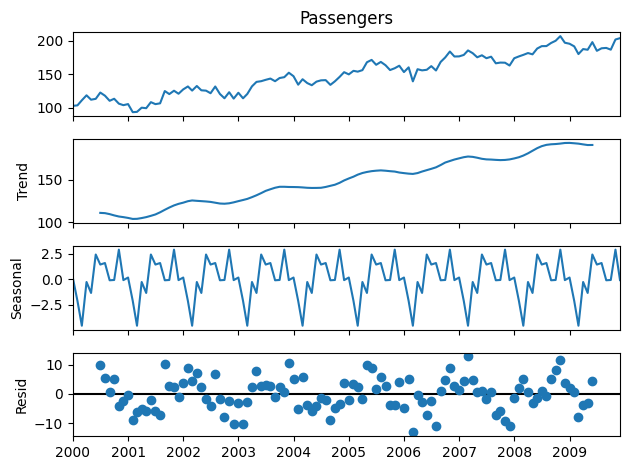

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Load dataset (using a sample AirPassengers style dataset)
# Generate sample data if not loading from CSV
np.random.seed(42)
dates = pd.date_range(start='2000-01-01', periods=120, freq='MS')
# Simulate trend, seasonality, and noise
trend = np.linspace(0, 100, 120)
seasonal = 10 * np.sin(np.linspace(0, 3 * np.pi, 120) * 4) # Approx 3 seasons over 10 years
noise = np.random.normal(0, 5, 120)
# Add some growth to simulate AirPassengers-like data
data = pd.Series(trend + seasonal + noise + 100, index=dates)
data.name = 'Passengers'

# If you have your own CSV, uncomment the lines below and adjust the path and column names
# df = pd.read_csv('your_data.csv', parse_dates=['Month'], index_col='Month')
# data = df['Passengers']

def plot_decomposition(series):
    # Decompose to see Trend, Seasonality, and Residuals
    result = seasonal_decompose(series, model='additive', period=12)
    result.plot()
    plt.tight_layout()
    plt.show()

plot_decomposition(data)

2. The Stationarity Workflow
You mentioned Log Transformation, Differencing, and Seasonal Detrending. Here is how to chain them together to pass the ADF Test.

In [8]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    return result[1] < 0.05

# Step A: Log Transform (Stabilize Variance)
data_log = np.log(data)

# Step B: Differencing (Remove Trend)
data_diff = data_log.diff().dropna()

# Step C: Seasonal Differencing (Remove Seasonality)
data_final = data_diff.diff(12).dropna()

check_stationarity(data_final)

ADF Statistic: -8.9111
p-value: 0.0000


np.True_

3. Identification (ACF & PACF)

In [3]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_correlation(series):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    plot_acf(series, ax=ax[0], lags=40) # Determines 'q'
    plot_pacf(series, ax=ax[1], lags=40) # Determines 'p'
    plt.show()

# plot_correlation(data_final)

4. Model Implementation (AR, MA, ARIMA, SARIMA)

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# --- AR Model (p=2, d=0, q=0) ---
model_ar = SARIMAX(data_final, order=(2, 0, 0)).fit()

# --- MA Model (p=0, d=0, q=2) ---
model_ma = SARIMAX(data_final, order=(0, 0, 2)).fit()

# --- ARIMA Model (p=1, d=1, q=1) ---
model_arima = SARIMAX(data_final, order=(1, 1, 1)).fit()

# --- SARIMA Model (Seasonal ARIMA) ---
# (p,d,q) x (P,D,Q)S
model_sarima = SARIMAX(data_final,
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12)).fit()

print(model_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  107
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 103.527
Date:                            Mon, 09 Mar 2026   AIC                           -197.054
Time:                                    16:36:51   BIC                           -184.338
Sample:                                02-01-2001   HQIC                          -191.918
                                     - 12-01-2009                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3362      0.104     -3.234      0.001      -0.540      -0.132
ma.L1         -0.9875      0.575   

5. Forecasting & Residual Diagnostics

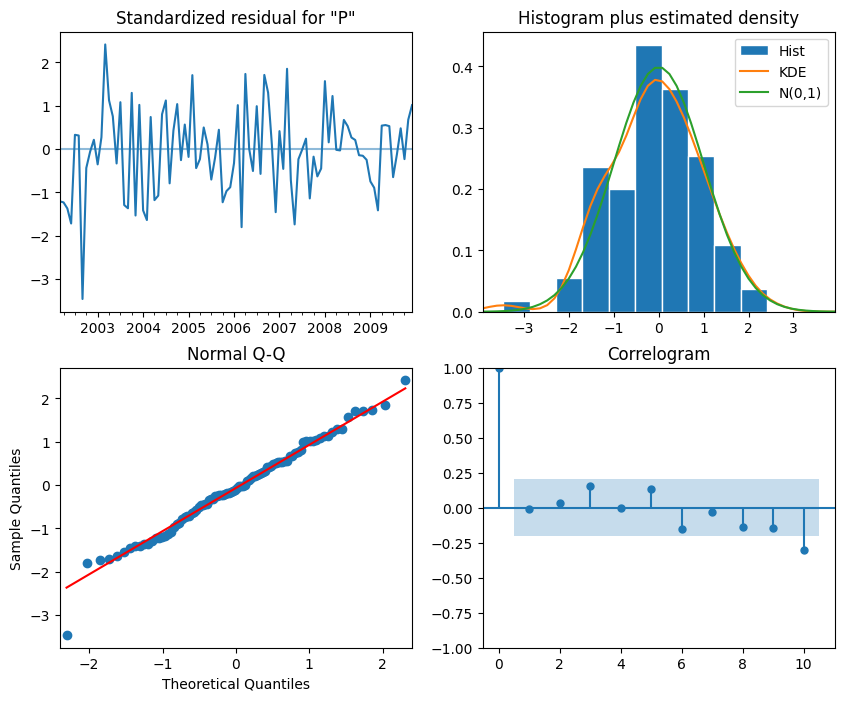

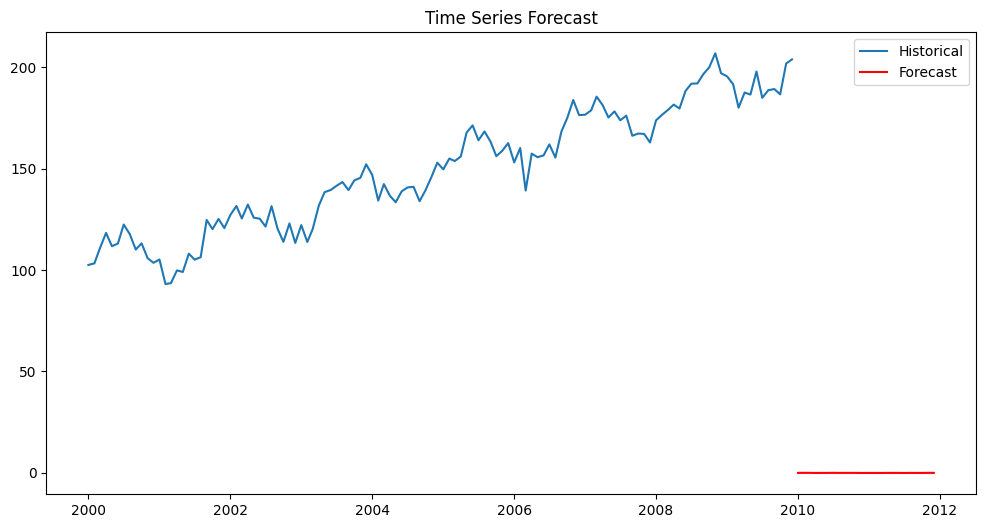

In [10]:
# 1. Check Residuals
model_sarima.plot_diagnostics(figsize=(10, 8))
plt.show()

# 2. Generate Forecast
forecast_steps = 24
forecast = model_sarima.get_forecast(steps=forecast_steps)
forecast_df = forecast.summary_frame()

# 3. Final Plot
plt.figure(figsize=(12, 6))
plt.plot(data, label='Historical')
plt.plot(forecast_df['mean'], color='red', label='Forecast')
plt.fill_between(forecast_df.index,
                 forecast_df['mean_ci_lower'],
                 forecast_df['mean_ci_upper'], color='pink', alpha=0.3)
plt.title('Time Series Forecast')
plt.legend()
plt.show()

6. Bonus: Auto-ARIMA (The Optimization Step)

In [14]:
!pip install pmdarima
import pmdarima as pm

auto_model = pm.auto_arima(data,
                           seasonal=True, m=12,
                           stepwise=True,
                           suppress_warnings=True)

print(f"Best Model Found: {auto_model.order} {auto_model.seasonal_order}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 34.0 MB/s eta 0:00:00
Best Model Found: (2, 1, 4) (1, 0, 0, 12)
